# BPSD — Behaviour-Guided Popularity Subspace Debiasing
## Full experimental record, MovieLens-1M

**Status: the hypothesis as formulated in the notes does not hold on ML-1M, and two
structural obstructions in the formulation were identified and measured.**

### What runs here

| Cell | Contents |
|---|---|
| 1 | Splits built from raw `ratings.dat` / `movies.dat`. PPAC-compatible protocol including the balanced (intervened) test and validation sets. No external files. |
| 2 | LightGCN backbone (Stage 1). |
| 3 | Behavioural profiles from genre metadata + timestamps (Stage 2). Deconfounding §7.8 OFF, as instructed. |
| 4 | PPD popularity proxies `p_i`, `r_ui`, `b_ui` (Stage 3). |
| 5 | **Stage 4 implemented exactly as §9.3–9.5 specify.** It collapses. |
| D1–D3 | Diagnostics establishing *why* it collapses. |
| 6 | Revised construction: shared orthonormal basis + removal strength α. |
| 7 | Trade-off sweep, tail recall on the raw holdout. |
| 8 | Matched-ARP comparison, K=1 vs K=4. |
| 9 | Summary of findings. |

### Headline numbers (seed 2020, single run)

Baseline LightGCN on the balanced test set: **Recall@50 0.3846, NDCG@50 0.2313,
ARP@50 0.3310**. PPAC (WWW'24) report 0.3757 / 0.2295 for their LightGCN baseline
and 0.4056 / 0.2481 for PPAC itself, but those come from a different pipeline and
are **not** directly comparable — see cell 9.

### Two structural findings

1. **§9.3–9.5 cannot produce K distinct directions.** The mode centroid is a mean
   over ~360k edges, so any partition of users — behavioural, random, or a learned
   hard 82/18 split — yields nearly the same popularity-weighted item mean.
   Measured max pairwise cosine: 1.0000 (soft gates), 0.9984 (random hard),
   1.0000 (learned hard). The collapse is algebraic.
2. **§9.1's softmax makes K non-identifiable.** Since Σ_k g_vk = 1, total removal
   energy is α regardless of K, so increasing K spreads a fixed budget thinner
   rather than adding capacity. Varying K at fixed α therefore cannot test the
   hypothesis.

### Result

Under a construction that *does* give distinct directions, K=1 beats K=4 at every
matched ARP level, and the gap widens as debiasing strengthens. Consistent with the
deflated spectrum (1.513, 1.401, 1.373, 1.343 — flat), popularity in this backbone
is effectively one-dimensional.

**Caveat: single seed. Variance across seeds has not been measured.**

In [1]:
# ============================================================================
# CELL 1 — CONFIG AND SPLITS
# ============================================================================
import os, sys, time, math, json, random, collections
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F

RAW_DATA_DIR = '/kaggle/input/datasets/tejasdeshmukh001/movielens'   # ratings.dat, movies.dat
WORKING_DIR  = '/kaggle/working/dataset/ml-1M'
CKPT_DIR     = '/kaggle/working/checkpoints'
os.makedirs(WORKING_DIR, exist_ok=True)
os.makedirs(CKPT_DIR, exist_ok=True)

SEED = 2020
POSITIVE_RATING_THRESHOLD = 4.0   # PPAC uses `rating > 3`
TEST_HOLDOUT_PER_USER     = 30    # PPAC's TOP_K
BALANCE_PER_ITEM          = None  # None -> derive it from your own holdout pool (see below)
VAL_HOLDOUT_PER_USER      = 20    # only used when STRICT_PPAC = False

# STRICT_PPAC = True  -> reproduce the paper's released protocol exactly:
#                        no validation split, checkpoint selected by NDCG@50 on the
#                        balanced test set (this is literally what run_MF.py does).
#                        Use this ONLY for the head-to-head number against Table 2.
# STRICT_PPAC = False -> carve a validation split and select on it. Honest, but the
#                        absolute numbers land a little below the paper's.
STRICT_PPAC = False

EVAL_ON_BALANCED = True   # True  -> balanced (intervened) test set  == paper's numbers
                          # False -> the raw 30-per-user holdout     == biased test set

TOP_KS = [20, 50, 100]
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


def set_seed(seed):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
    os.environ['PYTHONHASHSEED'] = str(seed)


def build_splits():
    """Reproduce PPAC's ml-1M split, plus its balanced (intervened) test set.

    PPAC (run_MF.py::create_train_and_test):
      * positives are ratings > 3
      * every user with MORE than 30 positives contributes exactly 30 to the test pool
      * every other user contributes all of their positives to train
      * NO global minimum-interaction user filter
      * NO validation split

    Balanced (intervened) test set: from the test pool, fix a per-item quota n,
    keep every item with at least n held-out interactions, and subsample exactly n
    of them. Every retained item then contributes the same number of test
    interactions, which is the property the protocol needs.

    n is not a free constant. Retained interactions = n * |{i : c_i >= n}|, which
    has an interior maximum: small n throws away interactions from popular items,
    large n throws away items entirely. BALANCE_PER_ITEM = None picks the argmax
    from THIS split's own item counts, so nothing is inherited from anywhere.

    Built entirely from ratings.dat and movies.dat. No external split files.
    """
    rng = random.Random(SEED)
    by_user = collections.defaultdict(list)
    rating_of = {}
    ts_of = {}

    with open(os.path.join(RAW_DATA_DIR, 'ratings.dat'), encoding='latin-1') as fh:
        for line in fh:
            u, i, r, t = line.strip().split('::')
            u, r, t = int(u), float(r), int(t)
            if r >= POSITIVE_RATING_THRESHOLD:
                by_user[u].append(i)
                rating_of[(u, i)] = r
                ts_of[(u, i)] = t

    train, val, test_pool = (collections.defaultdict(list) for _ in range(3))
    for u, items in by_user.items():
        items = list(items)
        rng.shuffle(items)
        need = TEST_HOLDOUT_PER_USER + (0 if STRICT_PPAC else VAL_HOLDOUT_PER_USER)
        if len(items) > need:
            test_pool[u] = items[:TEST_HOLDOUT_PER_USER]
            if not STRICT_PPAC:
                val[u] = items[TEST_HOLDOUT_PER_USER:need]
            train[u] = items[need:]
        else:
            train[u] = items

    # --- balanced / intervened sets -----------------------------------------
    def _balance(pool, quota=None):
        """Keep every item with >= n held-out interactions, subsample exactly n.

        n defaults to the argmax of retained(n) = n * |{i : c_i >= n}|, derived
        from this pool's own item counts. Applied to the validation pool as well
        as the test pool, so selection and reporting see the same kind of set.
        """
        hits = collections.defaultdict(list)
        for u, items in pool.items():
            for i in items:
                hits[i].append(u)
        counts = np.array(sorted(len(v) for v in hits.values()))
        retained = counts[::-1] * (np.arange(len(counts)) + 1)
        q = int(quota) if quota else int(counts[::-1][retained.argmax()])
        out, n_items = collections.defaultdict(list), 0
        for i, users in hits.items():
            if len(users) >= q:
                n_items += 1
                for u in rng.sample(users, q):
                    out[u].append(i)
        return out, q, n_items

    balanced, quota, n_bal_items = _balance(test_pool, BALANCE_PER_ITEM)

    print(f'[split] users={len(by_user)}  train_inter={sum(map(len, train.values()))}')
    print(f'[split] raw test: {len(test_pool)} users, {sum(map(len, test_pool.values()))} interactions')
    print(f'[split] balanced test: {len(balanced)} users, {sum(map(len, balanced.values()))} '
          f'interactions over {n_bal_items} items @ {quota} each')
    if not STRICT_PPAC:
        print(f'[split] val: {len(val)} users, {sum(map(len, val.values()))} interactions')

    def dump(name, recs):
        with open(os.path.join(WORKING_DIR, name), 'w', encoding='utf-8') as fh:
            for u, items in recs.items():
                for i in items:
                    fh.write(f'{u}::{i}::{rating_of[(u, i)]:.1f}::{ts_of[(u, i)]}\n')

    dump('ratings.train', train)
    dump('ratings.test', test_pool)
    dump('balance_ratings.test', balanced)
    if not STRICT_PPAC:
        dump('ratings.val', val)
        bal_val, vq, vn = _balance(val)
        print(f'[split] balanced val: {len(bal_val)} users, '
              f'{sum(map(len, bal_val.values()))} interactions over {vn} items @ {vq} each')
        dump('balance_ratings.val', bal_val)


def read_splits():
    """Load the splits and remap to compact 0-based ids."""
    item_map = {}
    with open(os.path.join(RAW_DATA_DIR, 'movies.dat'), encoding='latin-1') as fh:
        for idx, line in enumerate(fh):
            item_map[line.split('::')[0]] = idx

    def load(name):
        recs = collections.defaultdict(list)
        path = os.path.join(WORKING_DIR, name)
        if not os.path.exists(path):
            return recs
        with open(path, encoding='utf-8') as fh:
            for line in fh:
                u, i, _, _ = line.strip().split('::')
                recs[int(u)].append(item_map[i])
        return recs

    raw_train = load('ratings.train')
    user_map = {raw: new for new, raw in enumerate(sorted(raw_train))}
    train = collections.defaultdict(list, {user_map[u]: v for u, v in raw_train.items()})
    train_items = {i for v in train.values() for i in v}

    def rankable(name):
        out = collections.defaultdict(list)
        for u, items in load(name).items():
            if u not in user_map:
                continue
            keep = [i for i in items if i in train_items]
            if keep:
                out[user_map[u]] = keep
        return out

    test = rankable('balance_ratings.test' if EVAL_ON_BALANCED else 'ratings.test')
    val = rankable('balance_ratings.val' if EVAL_ON_BALANCED else 'ratings.val')
    if STRICT_PPAC:
        val = test          # paper protocol: selection happens on the eval set
    params = {'num_users': len(user_map), 'num_items': len(item_map)}
    return train, val, test, user_map, item_map, params


set_seed(SEED)
build_splits()
train_records, val_records, test_records, user_map, item_map, params = read_splits()
NUM_USERS, NUM_ITEMS = params['num_users'], params['num_items']
print(f'[data] users={NUM_USERS} items={NUM_ITEMS} '
      f'train={sum(map(len, train_records.values()))} '
      f'val_users={len(val_records)} test_users={len(test_records)}')

[split] users=6038  train_inter=408831
[split] raw test: 3329 users, 99870 interactions
[split] balanced test: 3329 users, 29882 interactions over 446 items @ 67 each
[split] val: 3329 users, 66580 interactions
[split] balanced val: 3325 users, 19932 interactions over 453 items @ 44 each
[data] users=6038 items=3883 train=408831 val_users=3325 test_users=3329


In [2]:
# ============================================================================
# CELL 2 — STAGE 1: LIGHTGCN BACKBONE
# ============================================================================
LATENT_DIM = 64
N_LAYERS   = 3
LR         = 1e-3       # paper reports 0.01; 1e-3 is the released-code default
REG_WEIGHT = 1e-4
BATCH_SIZE = 8192
EPOCHS     = 2000
PATIENCE   = 50


def build_sparse_adj(train_recs, num_users, num_items):
    n = num_users + num_items
    us, it = [], []
    for u, items in train_recs.items():
        us.extend([u] * len(items))
        it.extend([i + num_users for i in items])
    us = torch.tensor(us, dtype=torch.long)
    it = torch.tensor(it, dtype=torch.long)
    src = torch.cat([us, it]); dst = torch.cat([it, us])
    deg = torch.zeros(n).scatter_add_(0, dst, torch.ones(dst.numel()))
    dis = deg.clamp(min=1.0).pow(-0.5)
    return torch.sparse_coo_tensor(
        torch.stack([dst, src]), dis[dst] * dis[src], (n, n)).coalesce()


def propagate(adj, e_u0, e_i0, n_layers=N_LAYERS):
    """LightGCN readout: mean over layers 0..L (alpha_l = 1/(L+1))."""
    x = torch.cat([e_u0, e_i0], dim=0)
    layers = [x]
    for _ in range(n_layers):
        x = torch.sparse.mm(adj, x)
        layers.append(x)
    out = torch.stack(layers, dim=1).mean(dim=1)
    return torch.split(out, [e_u0.shape[0], e_i0.shape[0]], dim=0)


def sample_triplets(train_recs, num_items):
    users, pos = [], []
    for u, items in train_recs.items():
        users.extend([u] * len(items)); pos.extend(items)
    users = np.asarray(users, dtype=np.int64); pos = np.asarray(pos, dtype=np.int64)
    psets = {u: set(v) for u, v in train_recs.items()}
    neg = np.random.randint(0, num_items, size=len(users), dtype=np.int64)
    bad = np.fromiter((n in psets[u] for u, n in zip(users, neg)), bool, len(users))
    while bad.any():
        idx = np.flatnonzero(bad)
        neg[idx] = np.random.randint(0, num_items, size=len(idx), dtype=np.int64)
        bad[idx] = np.fromiter((neg[j] in psets[users[j]] for j in idx), bool, len(idx))
    return torch.from_numpy(users), torch.from_numpy(pos), torch.from_numpy(neg)


def recall_ndcg(ground_truth, ranked, k):
    disc = 1.0 / np.log2(np.arange(2, k + 2))
    rec, ndcg = [], []
    for truth, row in zip(ground_truth, ranked):
        ts = set(truth)
        hits = np.fromiter((i in ts for i in row[:k]), np.float32, k)
        rec.append(hits.sum() / len(ts))
        idcg = disc[:min(len(ts), k)].sum()
        ndcg.append(float((hits * disc).sum()) / idcg if idcg > 0 else 0.0)
    return float(np.mean(rec)), float(np.mean(ndcg))


@torch.no_grad()
def evaluate(e_u, e_i, eval_recs, exclude_recs, item_pop, ks=TOP_KS):
    users = sorted(u for u, v in eval_recs.items() if v)
    max_k = max(ks)
    ranked_all = []
    for s in range(0, len(users), 512):
        batch = users[s:s + 512]
        scores = e_u[batch] @ e_i.T
        for r, u in enumerate(batch):
            ex = exclude_recs.get(u, [])
            if ex:
                scores[r, torch.tensor(ex, dtype=torch.long, device=scores.device)] = -torch.inf
        ranked_all.append(torch.topk(scores, k=max_k, dim=1).indices.cpu().numpy())
    ranked = np.concatenate(ranked_all, 0)
    truth = [eval_recs[u] for u in users]

    out = {}
    for k in ks:
        r, n = recall_ndcg(truth, ranked, k)
        out[k] = {'recall': r, 'ndcg': n, 'arp': float(item_pop[ranked[:, :k]].mean())}
    # Bottom-20% of items that actually appear in training (notes S15.9).
    # A median split over ALL items sweeps in the several hundred movies with
    # zero training interactions, which no model can rank, so the old version
    # measured mostly unrankable items.
    present = np.flatnonzero(item_pop > 0)
    cut = np.quantile(item_pop[present], 0.2)
    tail = set(present[item_pop[present] <= cut].tolist())
    tt = [[i for i in t if i in tail] for t in truth]
    keep = [j for j, t in enumerate(tt) if t]
    out['tail_recall@50'] = recall_ndcg([tt[j] for j in keep], ranked[keep], 50)[0] if keep else 0.0
    return out


class LightGCN(nn.Module):
    def __init__(self, num_users, num_items, dim=LATENT_DIM):
        super().__init__()
        self.user_embedding = nn.Embedding(num_users, dim)
        self.item_embedding = nn.Embedding(num_items, dim)
        nn.init.normal_(self.user_embedding.weight, std=0.1)
        nn.init.normal_(self.item_embedding.weight, std=0.1)

    def readout(self, adj):
        return propagate(adj, self.user_embedding.weight, self.item_embedding.weight)


def item_popularity_from(train_recs, num_items):
    c = np.zeros(num_items, dtype=np.float32)
    for items in train_recs.values():
        c[np.asarray(items, dtype=np.int64)] += 1.0
    return c / max(float(c.max()), 1.0)


def train_backbone():
    set_seed(SEED)
    adj = build_sparse_adj(train_records, NUM_USERS, NUM_ITEMS).to(DEVICE)
    model = LightGCN(NUM_USERS, NUM_ITEMS).to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=LR)
    item_pop = item_popularity_from(train_records, NUM_ITEMS)
    ckpt = os.path.join(CKPT_DIR, 'lightgcn-ml1m.pt')

    best, best_ep = -np.inf, -1
    for epoch in range(EPOCHS):
        model.train(); t0 = time.time()
        u, p, n = sample_triplets(train_records, NUM_ITEMS)
        perm = torch.randperm(len(u)); u, p, n = u[perm], p[perm], n[perm]
        tot = 0.0; nb = 0
        for s in range(0, len(u), BATCH_SIZE):
            ub = u[s:s+BATCH_SIZE].to(DEVICE)
            pb = p[s:s+BATCH_SIZE].to(DEVICE)
            nb_ = n[s:s+BATCH_SIZE].to(DEVICE)
            opt.zero_grad(set_to_none=True)
            eu, ei = model.readout(adj)
            pos = (eu[ub] * ei[pb]).sum(1)
            neg = (eu[ub] * ei[nb_]).sum(1)
            rank = F.softplus(neg - pos).mean()
            ego = (model.user_embedding(ub).pow(2).sum()
                   + model.item_embedding(pb).pow(2).sum()
                   + model.item_embedding(nb_).pow(2).sum()) / (2.0 * len(ub))
            loss = rank + REG_WEIGHT * ego
            loss.backward(); opt.step()
            tot += loss.item(); nb += 1

        model.eval()
        with torch.no_grad():
            eu, ei = model.readout(adj)
            m = evaluate(eu, ei, val_records, train_records, item_pop)
        if m[50]['ndcg'] > best:
            best, best_ep = m[50]['ndcg'], epoch
            torch.save({'epoch': epoch, 'model_state_dict': model.state_dict()}, ckpt)
        print(f'Epoch [{epoch+1}/{EPOCHS}] Loss {tot/nb:.4f} '
              f'Recall@50 {m[50]["recall"]:.4f} NDCG@50 {m[50]["ndcg"]:.4f} '
              f'ARP@50 {m[50]["arp"]:.4f} {time.time()-t0:.1f}s')
        if epoch - best_ep >= PATIENCE:
            print(f'Early stop at {epoch+1}; best epoch {best_ep+1}'); break

    model.load_state_dict(torch.load(ckpt, map_location=DEVICE)['model_state_dict'])
    torch.save({'adjacency': adj.cpu().coalesce(),
                'num_users': NUM_USERS, 'num_items': NUM_ITEMS},
               '/kaggle/working/sparse_adj_matrix.pt')
    model.eval()
    with torch.no_grad():
        eu, ei = model.readout(adj)
        # Mask training positives only, matching PPAC's test_model and the
        # validation call above, so val and test use one candidate protocol.
        m = evaluate(eu, ei, test_records, train_records, item_pop)
    print('\n--- BASELINE LightGCN (test) ---')
    for k in TOP_KS:
        print(f'Recall@{k} {m[k]["recall"]:.4f}  NDCG@{k} {m[k]["ndcg"]:.4f}  ARP@{k} {m[k]["arp"]:.4f}')
    return model, adj, item_pop


backbone, sparse_adj, item_pop = train_backbone()

Epoch [1/2000] Loss 0.6809 Recall@50 0.1458 NDCG@50 0.0704 ARP@50 0.5144 3.2s
Epoch [2/2000] Loss 0.5459 Recall@50 0.1443 NDCG@50 0.0696 ARP@50 0.5175 2.1s
Epoch [3/2000] Loss 0.3813 Recall@50 0.1436 NDCG@50 0.0694 ARP@50 0.5174 2.0s
Epoch [4/2000] Loss 0.3273 Recall@50 0.1435 NDCG@50 0.0694 ARP@50 0.5174 2.0s
Epoch [5/2000] Loss 0.3142 Recall@50 0.1436 NDCG@50 0.0694 ARP@50 0.5175 2.0s
Epoch [6/2000] Loss 0.3089 Recall@50 0.1438 NDCG@50 0.0695 ARP@50 0.5177 2.0s
Epoch [7/2000] Loss 0.3068 Recall@50 0.1441 NDCG@50 0.0697 ARP@50 0.5177 2.0s
Epoch [8/2000] Loss 0.3048 Recall@50 0.1437 NDCG@50 0.0695 ARP@50 0.5179 2.0s
Epoch [9/2000] Loss 0.3043 Recall@50 0.1444 NDCG@50 0.0697 ARP@50 0.5180 2.0s
Epoch [10/2000] Loss 0.3018 Recall@50 0.1452 NDCG@50 0.0700 ARP@50 0.5181 2.0s
Epoch [11/2000] Loss 0.2993 Recall@50 0.1447 NDCG@50 0.0699 ARP@50 0.5181 2.0s
Epoch [12/2000] Loss 0.2985 Recall@50 0.1454 NDCG@50 0.0701 ARP@50 0.5182 2.0s
Epoch [13/2000] Loss 0.2974 Recall@50 0.1456 NDCG@50 0.0703 A

In [3]:
# ============================================================================
# CELL 3 — STAGE 2: BEHAVIOURAL PROFILES (§7)
# ============================================================================
# Deviation from the old notebook: categories and content vectors come from
# movies.dat genres, NOT from KMeans on the LightGCN item embeddings. Clustering
# the backbone's own embeddings makes q_u a function of the representation being
# debiased -- the profiles then re-encode the popularity signal they are supposed
# to be independent of, and §7 says these come from metadata.
from scipy.stats import spearmanr, entropy
from sklearn.cluster import KMeans

N_CATEGORIES  = 20
CATEGORY_MODE = 'kmeans_genre'   # 'kmeans_genre' | 'primary_genre'
WINDOW_DAYS   = 30               # §7.3 uses *time* windows, not fixed-count chunks
MIN_WINDOW_INTERACTIONS = 3
LOYALTY_WEIGHT = 'count'         # 'count' matches §7.6 with w_ui = #interactions
DECONFOUND = False               # §7.8 -- OFF, as requested
PROXY_COLS = ['diversity', 'temporal_stability', 'exploration', 'cross_category', 'loyalty']


def build_item_metadata(item_map, n_categories=N_CATEGORIES):
    """Genre multi-hot content vectors + one category per item, from movies.dat."""
    genres_of = {}
    vocab = {}
    with open(os.path.join(RAW_DATA_DIR, 'movies.dat'), encoding='latin-1') as fh:
        for line in fh:
            mid, _, gstr = line.strip().split('::')
            gs = gstr.split('|')
            genres_of[item_map[mid]] = gs
            for g in gs:
                vocab.setdefault(g, len(vocab))

    content = np.zeros((len(item_map), len(vocab)), dtype=np.float32)
    for i, gs in genres_of.items():
        for g in gs:
            content[i, vocab[g]] = 1.0
    content /= np.maximum(np.linalg.norm(content, axis=1, keepdims=True), 1e-9)

    if CATEGORY_MODE == 'primary_genre':
        freq = collections.Counter(g for gs in genres_of.values() for g in gs)
        cat = np.array([vocab[min(genres_of[i], key=lambda g: freq[g])]
                        for i in range(len(item_map))], dtype=np.int64)
    else:
        km = KMeans(n_clusters=min(n_categories, len(item_map)), random_state=42, n_init=10)
        cat = km.fit_predict(content).astype(np.int64)
    return content, cat, int(cat.max()) + 1


def user_profiles(interactions, content, category, n_cats):
    """§7.2-7.7. interactions: DataFrame[user, item, rating, timestamp]."""
    recs = []
    for uid, grp in interactions.groupby('user', sort=True):
        items = grp['item'].to_numpy()
        if len(items) < 2:
            continue
        cats = category[items]

        # §7.2 diversity: mean pairwise (1 - cos) over CONTENT vectors
        V = content[items]
        S = V @ V.T
        iu = np.triu_indices(len(items), k=1)
        diversity = float((1.0 - S[iu]).mean())

        # §7.5 cross-category reach: Shannon entropy of P(c|u)
        counts = np.bincount(cats, minlength=n_cats).astype(np.float64)
        probs = counts[counts > 0] / counts.sum()
        cross = float(entropy(probs))

        # §7.4 exploration: fraction of items outside the user's top-3 categories
        top3 = set(np.argsort(-counts)[:3].tolist())
        exploration = float(np.mean([c not in top3 for c in cats]))

        # §7.6 loyalty
        w = (grp['rating'].to_numpy(np.float64) if LOYALTY_WEIGHT == 'rating'
             else np.ones(len(items)))
        agg = np.bincount(pd.factorize(items)[0], weights=w)
        loyalty = float(((agg / agg.sum()) ** 2).sum())

        # §7.3 temporal stability: Spearman between the FULL n_cats-length category
        # histograms of consecutive TIME windows.
        ts = grp['timestamp'].to_numpy(np.int64)
        order = np.argsort(ts)
        ts_o, cats_o = ts[order], cats[order]
        span = WINDOW_DAYS * 86400
        wins, cur, start = [], [], ts_o[0]
        for t, c in zip(ts_o, cats_o):
            if t - start > span and len(cur) >= MIN_WINDOW_INTERACTIONS:
                wins.append(cur); cur, start = [], t
            cur.append(c)
        if len(cur) >= MIN_WINDOW_INTERACTIONS:
            wins.append(cur)
        if len(wins) < 2:                       # fallback: equal-count halves
            half = len(cats_o) // 2
            wins = [cats_o[:half].tolist(), cats_o[half:].tolist()] if half >= 1 else []
        rhos = []
        for a, b in zip(wins[:-1], wins[1:]):
            ha = np.bincount(np.asarray(a), minlength=n_cats).astype(np.float64)
            hb = np.bincount(np.asarray(b), minlength=n_cats).astype(np.float64)
            if ha.std() > 0 and hb.std() > 0:
                rho = spearmanr(ha, hb).statistic
                if not np.isnan(rho):
                    rhos.append(rho)
        temporal = float(np.mean(rhos)) if rhos else 0.0

        recs.append({'user': uid, 'diversity': diversity, 'temporal_stability': temporal,
                     'exploration': exploration, 'cross_category': cross,
                     'loyalty': loyalty, '_degree': len(items)})

    df = pd.DataFrame(recs)
    for c in PROXY_COLS:                                       # §7.7 min-max
        lo, hi = df[c].min(), df[c].max()
        df[c] = (df[c] - lo) / (hi - lo + 1e-8)
    if DECONFOUND:                                             # §7.8 -- OFF
        bins = pd.qcut(df['_degree'], q=10, labels=False, duplicates='drop')
        for c in PROXY_COLS:
            df[c] = df[c] - df.groupby(bins)[c].transform('mean')
    return df.drop(columns=['_degree'])


def build_profiles():
    inter = []
    inv_item = {v: k for k, v in item_map.items()}
    ts_lookup = {}
    with open(os.path.join(RAW_DATA_DIR, 'ratings.dat'), encoding='latin-1') as fh:
        for line in fh:
            u, i, r, t = line.strip().split('::')
            ts_lookup[(int(u), i)] = (float(r), int(t))
    inv_user = {v: k for k, v in user_map.items()}
    for u, items in train_records.items():
        ru = inv_user[u]
        for i in items:
            r, t = ts_lookup[(ru, inv_item[i])]
            inter.append((u, i, r, t))
    df = pd.DataFrame(inter, columns=['user', 'item', 'rating', 'timestamp'])

    content, category, n_cats = build_item_metadata(item_map)
    q_u_df = user_profiles(df, content, category, n_cats)
    print(f'[stage2] q_u for {len(q_u_df)}/{NUM_USERS} users, {n_cats} categories')

    # §7.9 q_i = mean of q_u over N(i); unseen items get the COLUMN MEAN, not 0
    # (0 is the minimum after min-max normalisation, not a neutral value).
    q_i_df = (df[['user', 'item']].merge(q_u_df, on='user', how='inner')
              .groupby('item')[PROXY_COLS].mean().reset_index())
    q_i_df = pd.DataFrame({'item': np.arange(NUM_ITEMS)}).merge(q_i_df, on='item', how='left')
    q_i_df[PROXY_COLS] = q_i_df[PROXY_COLS].fillna(q_i_df[PROXY_COLS].mean())

    q_u = np.tile(q_u_df[PROXY_COLS].mean().to_numpy(np.float32), (NUM_USERS, 1))
    q_u[q_u_df['user'].to_numpy(np.int64)] = q_u_df[PROXY_COLS].to_numpy(np.float32)
    q_i = q_i_df[PROXY_COLS].to_numpy(np.float32)

    q_u_df.to_csv('/kaggle/working/q_u_profiles.csv', index=False)
    q_i_df.to_csv('/kaggle/working/q_i_profiles.csv', index=False)
    return torch.tensor(q_u, device=DEVICE), torch.tensor(q_i, device=DEVICE), df


q_u, q_i, interactions_df = build_profiles()

[stage2] q_u for 6001/6038 users, 20 categories


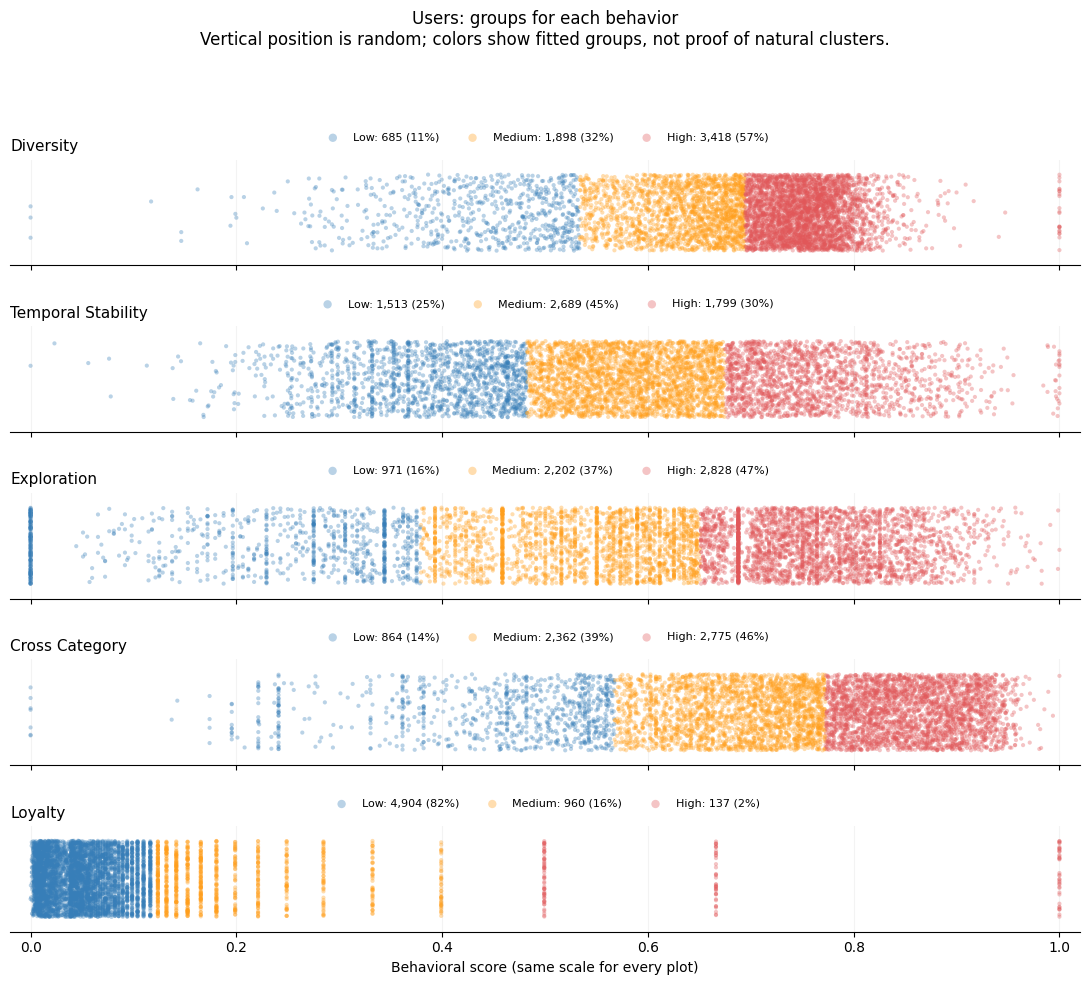

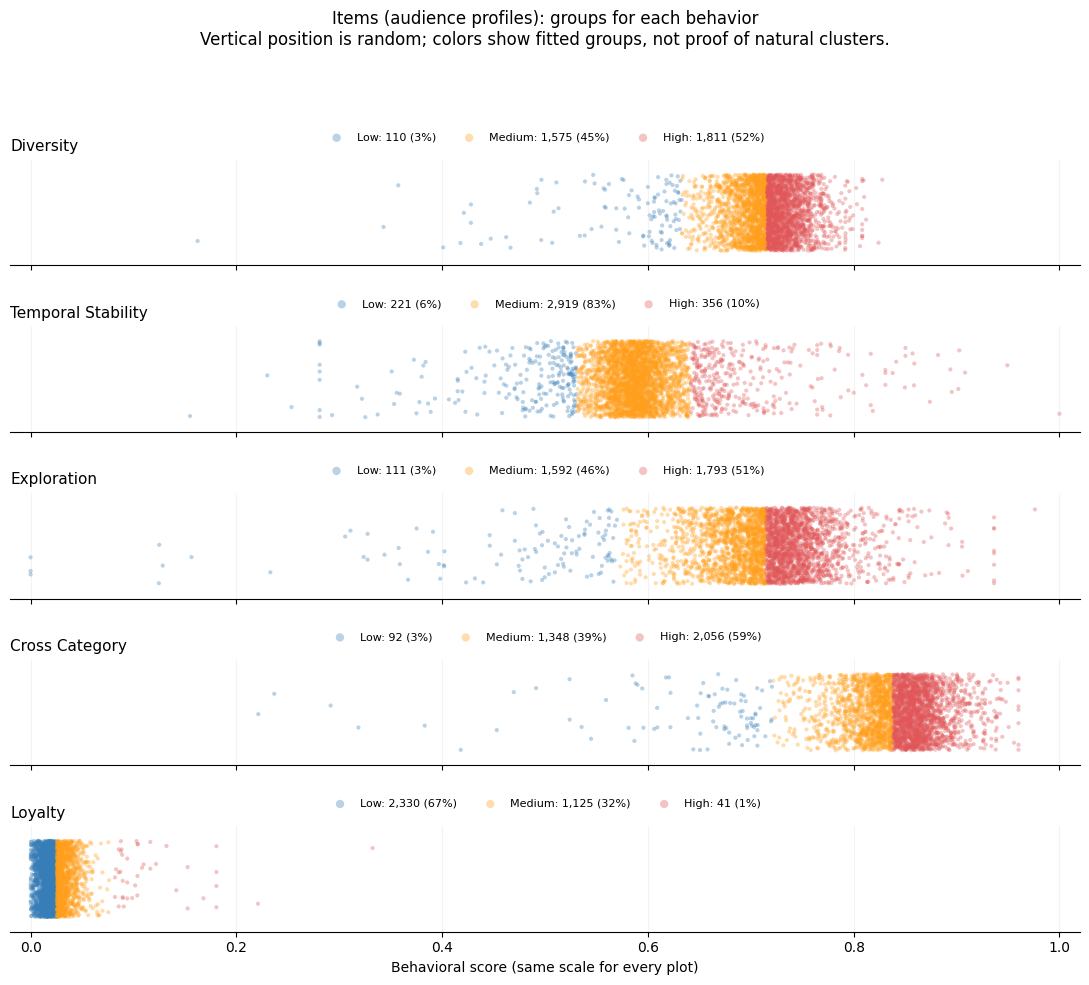

Three groups are requested per behavior; fewer are used if scores have too few distinct values.
Low/medium/high are relative to each fitted distribution; their boundaries can differ between plots.


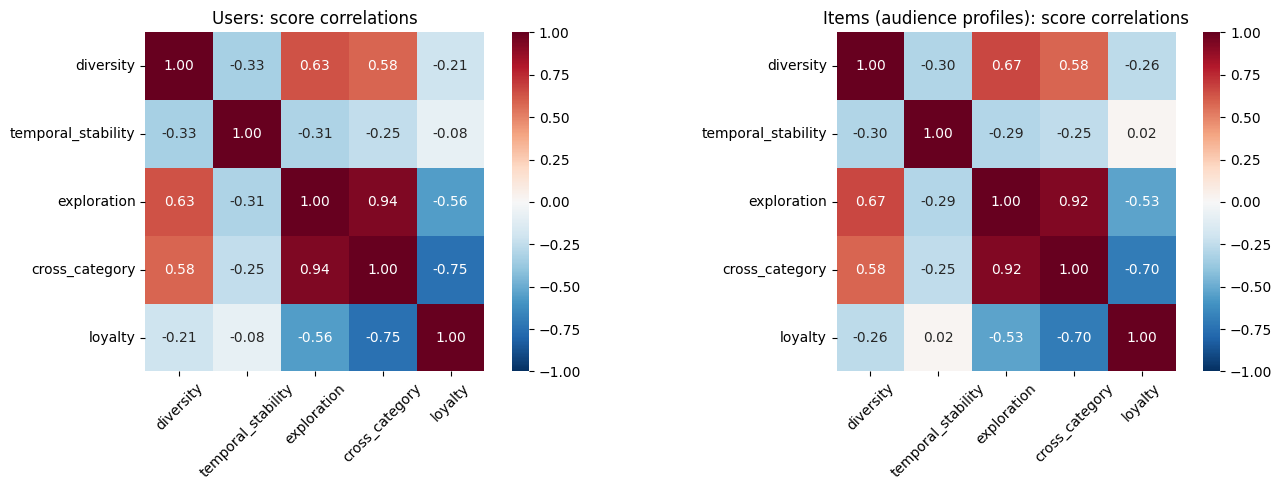

Near +1 or -1: strong overlap in score rankings. Near 0: little monotonic association.
A weak correlation does not prove that a score measures the intended behavior.
Blank cells indicate an undefined correlation, usually a constant score.

BASIC CHECKS
Observed profiles: 6,001 users; 3,496 items
Users with repeated items: 0 / 6,001
Users with at least two time windows: 1,168 / 6,001
Users using the equal-count-halves fallback: 4,833 / 6,001
Users with a retained window exceeding 30 days: 517
LOYALTY: every raw score equals 1 / interaction count; this is inverse activity.
EXPLORATION: the current formula measures consumption outside overall top-three categories, not novelty over time.

SELECTED EXAMPLES — randomly sampled within low/high tails (including ties)


,behavior,level,user,score,interactions,distinct_items,repeat_interactions,history_days,time_windows,uses_halves_fallback,has_extended_window
0,diversity,Low,459,0.281,26,26,0,0.015,1,True,False
1,diversity,High,4651,0.831,10,10,0,3.448,1,True,False
2,temporal_stability,Low,4079,0.340,39,39,0,0.012,1,True,False
3,temporal_stability,High,2474,0.839,26,26,0,0.003,1,True,False
4,exploration,Low,2641,0.000,3,3,0,0.006,1,True,False
5,exploration,High,5265,0.833,142,142,0,0.056,1,True,False
6,cross_category,Low,596,0.241,2,2,0,0.001,0,True,False
7,cross_category,High,4326,0.956,142,142,0,573.882,2,False,False
8,loyalty,Low,1210,0.008,209,209,0,595.904,5,False,False
9,loyalty,High,552,0.399,5,5,0,0.039,1,True,False



Saved evidence for interpretation: /kaggle/working/behavior_checks.json
These examples are a qualitative spot-check, not proof covering all users.


In [5]:
# Paste this cell after the cell that creates q_u, q_i and interactions_df.
# Uses your current profiles without changing their definitions.

from pathlib import Path
from html import escape
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from IPython.display import display, HTML

BEHAVIORS = [
    'diversity', 'temporal_stability', 'exploration',
    'cross_category', 'loyalty'
]

def numpy_array(x):
    return x.detach().cpu().numpy() if hasattr(x, 'detach') else np.asarray(x)

# Keep only profiles supported by observations, excluding mean-filled profiles.
inter = interactions_df.copy()
counts = inter.groupby('user').size()
user_ids = counts[counts >= 2].index.to_numpy(dtype=int)
inter = inter[inter['user'].isin(user_ids)].copy()
item_ids = np.sort(inter['item'].unique().astype(int))
users = pd.DataFrame(numpy_array(q_u)[user_ids], index=user_ids, columns=BEHAVIORS)
items = pd.DataFrame(numpy_array(q_i)[item_ids], index=item_ids, columns=BEHAVIORS)
users.index.name = 'user'
items.index.name = 'item'

if not np.isfinite(users.to_numpy()).all() or not np.isfinite(items.to_numpy()).all():
    raise ValueError('Profiles contain non-finite scores; inspect those before proceeding.')
if users.empty or items.empty:
    raise ValueError('No observed profiles are available for this analysis.')

# ---------------------------------------------------------------------------
# 1. SCATTER PLOTS: low/medium/high groups fitted separately for each behavior.
# X = score. Y = random jitter only, to make overlapping points visible.
# ---------------------------------------------------------------------------
# Your current min-max profiles use 0-1. If settings change and scores exceed
# that range, expand the SAME axis for all plots rather than hiding points.
score_min = min(0.0, users.to_numpy().min(), items.to_numpy().min())
score_max = max(1.0, users.to_numpy().max(), items.to_numpy().max())
padding = .02 * (score_max - score_min)
shared_limits = (score_min - padding, score_max + padding)

def scatter_behavior_groups(profiles, title):
    colors = {'Low': '#377eb8', 'Medium': '#ff9f1c',
              'High': '#e15759', 'Single': '#777777'}
    labels = pd.DataFrame(index=profiles.index)
    summary_rows = []
    jitter_rng = np.random.default_rng(42)
    fig, axes = plt.subplots(5, 1, figsize=(11, 10), sharex=True)

    for ax, behavior in zip(axes, BEHAVIORS):
        scores = profiles[behavior].to_numpy()
        k = min(3, len(np.unique(scores)))
        model = KMeans(n_clusters=k, random_state=42, n_init=20)
        raw_labels = model.fit_predict(scores.reshape(-1, 1))
        ordered = sorted(np.unique(raw_labels),
                         key=lambda label: scores[raw_labels == label].mean())
        names = {1: ['Single'], 2: ['Low', 'High'],
                 3: ['Low', 'Medium', 'High']}[len(ordered)]
        mapping = dict(zip(ordered, names))
        labels[behavior] = [mapping[label] for label in raw_labels]
        jitter = jitter_rng.uniform(-.18, .18, len(scores))

        for name in names:
            mask = labels[behavior].to_numpy() == name
            values = scores[mask]
            ax.scatter(values, jitter[mask], color=colors[name], s=9,
                       alpha=.35, edgecolors='none', rasterized=True,
                       label=f'{name}: {len(values):,} ({mask.mean():.0%})')
            summary_rows.append({'behavior': behavior, 'group': name,
                                 'count': len(values), 'percent': 100 * mask.mean(),
                                 'min': values.min(), 'mean': values.mean(),
                                 'max': values.max()})
        ax.set_title(behavior.replace('_', ' ').title(), loc='left', fontsize=11)
        ax.set_yticks([])
        ax.set_ylim(-.25, .25)
        ax.set_xlim(*shared_limits)
        ax.legend(loc='upper center', bbox_to_anchor=(.5, 1.35),
                  ncol=len(names), frameon=False, fontsize=8, markerscale=2)
        ax.grid(axis='x', alpha=.15)
        for side in ['top', 'right', 'left']:
            ax.spines[side].set_visible(False)

    axes[-1].set_xlabel('Behavioral score (same scale for every plot)')
    fig.suptitle(title + ': groups for each behavior\n'
                 'Vertical position is random; colors show fitted groups, not proof of natural clusters.',
                 fontsize=12)
    fig.tight_layout(rect=(0, 0, 1, .94))
    plt.show()
    return labels, pd.DataFrame(summary_rows)

user_groups, user_group_summary = scatter_behavior_groups(users, 'Users')
item_groups, item_group_summary = scatter_behavior_groups(items, 'Items (audience profiles)')
print('Three groups are requested per behavior; fewer are used if scores have too few distinct values.')
print('Low/medium/high are relative to each fitted distribution; their boundaries can differ between plots.')

# ---------------------------------------------------------------------------
# 2. CORRELATION HEATMAPS: overlap between scores for users and for items.
# ---------------------------------------------------------------------------
user_correlations = users.corr(method='spearman')
item_correlations = items.corr(method='spearman')
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, corr, title in zip(
    axes, [user_correlations, item_correlations], ['Users', 'Items (audience profiles)']
):
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r',
                vmin=-1, vmax=1, center=0, square=True, ax=ax)
    ax.set_title(title + ': score correlations')
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()
print('Near +1 or -1: strong overlap in score rankings. Near 0: little monotonic association.')
print('A weak correlation does not prove that a score measures the intended behavior.')
print('Blank cells indicate an undefined correlation, usually a constant score.\n')

# ---------------------------------------------------------------------------
# 3. BASIC VALIDITY CHECKS: repeat interactions and time-window support.
# Reproduce your window construction, BEFORE the equal-count-halves fallback.
# ---------------------------------------------------------------------------
def original_time_windows(group):
    ordered = group.sort_values('timestamp', kind='stable')
    windows, current = [], []
    start = None
    for row_id, timestamp in zip(ordered.index, ordered['timestamp']):
        if start is None:
            start = timestamp
        if timestamp - start > WINDOW_DAYS * 86400 and len(current) >= MIN_WINDOW_INTERACTIONS:
            windows.append(current)
            current, start = [], timestamp
        current.append(row_id)
    if len(current) >= MIN_WINDOW_INTERACTIONS:
        windows.append(current)
    return windows

# Reset the row index so window membership remains unambiguous.
inter = inter.reset_index(drop=True)
facts = []
for uid, group in inter.groupby('user'):
    windows = original_time_windows(group)
    extended = sum(
        inter.loc[w, 'timestamp'].max() - inter.loc[w, 'timestamp'].min()
        > WINDOW_DAYS * 86400 for w in windows
    )
    facts.append({
        'user': uid,
        'interactions': len(group),
        'distinct_items': group['item'].nunique(),
        'repeat_interactions': len(group) - group['item'].nunique(),
        'history_days': (group['timestamp'].max() - group['timestamp'].min()) / 86400,
        'time_windows': len(windows),
        'uses_halves_fallback': len(windows) < 2,
        'has_extended_window': extended > 0,
    })
facts = pd.DataFrame(facts).set_index('user')

print('BASIC CHECKS')
print(f'Observed profiles: {len(users):,} users; {len(items):,} items')
print(f'Users with repeated items: {(facts.repeat_interactions > 0).sum():,} / {len(facts):,}')
print(f'Users with at least two time windows: {(facts.time_windows >= 2).sum():,} / {len(facts):,}')
print(f'Users using the equal-count-halves fallback: {facts.uses_halves_fallback.sum():,} / {len(facts):,}')
print(f'Users with a retained window exceeding {WINDOW_DAYS} days: {facts.has_extended_window.sum():,}')
if LOYALTY_WEIGHT == 'count' and facts.repeat_interactions.sum() == 0:
    print('LOYALTY: every raw score equals 1 / interaction count; this is inverse activity.')
print('EXPLORATION: the current formula measures consumption outside overall top-three categories, not novelty over time.')

# ---------------------------------------------------------------------------
# 4. HISTORY REVIEW: one random user from the bottom and top 10% per score.
# The same user may legitimately be selected for multiple behaviors.
# ---------------------------------------------------------------------------
rng = np.random.default_rng(42)
selections = []
for behavior in BEHAVIORS:
    if users[behavior].nunique() < 2:
        print(f'Cannot compare low/high {behavior}: all scores are identical.')
        continue
    low_cutoff, high_cutoff = users[behavior].quantile([.10, .90])
    if low_cutoff >= high_cutoff:
        low_cutoff, high_cutoff = users[behavior].min(), users[behavior].max()
        print(f'{behavior}: tied deciles; sampling from minimum/maximum scores instead.')
    for level, threshold in [('Low', low_cutoff), ('High', high_cutoff)]:
        pool = users.index[
            users[behavior] <= threshold if level == 'Low'
            else users[behavior] >= threshold
        ]
        uid = int(rng.choice(pool))
        selections.append({'behavior': behavior, 'level': level, 'user': uid,
                           'score': users.loc[uid, behavior]})
selected = pd.DataFrame(selections, columns=['behavior', 'level', 'user', 'score'])
summary = selected.merge(facts.reset_index(), on='user', how='left')
print('\nSELECTED EXAMPLES — randomly sampled within low/high tails (including ties)')
display(summary.round(3))

# Attach real movie titles and genres for inspection of the underlying history.
movie_rows = []
with open(Path(RAW_DATA_DIR) / 'movies.dat', encoding='latin-1') as fh:
    for line in fh:
        movie_id, title, genres = line.rstrip('\n').split('::')
        if movie_id in item_map:
            movie_rows.append({'item': item_map[movie_id], 'title': title, 'genres': genres})
movies = pd.DataFrame(movie_rows)
histories = inter[inter['user'].isin(selected['user'])].merge(movies, on='item', how='left')
histories['date'] = pd.to_datetime(histories['timestamp'], unit='s', utc=True)
histories = histories.sort_values(['user', 'timestamp'])

review_prompts = {
    'diversity': 'Does the high-score user consume more dissimilar genre combinations than the low-score user?',
    'temporal_stability': 'Do genre preferences persist across dates? Check whether the score uses the halves fallback.',
    'exploration': 'Does the high-score user consume outside their usual categories? Distinguish this from genuinely trying new categories.',
    'cross_category': 'Is the high-score history spread more broadly and evenly across categories?',
    'loyalty': 'Does the high-score user actually return to the same items, or simply have fewer interactions?',
}
for behavior, selection in selected.groupby('behavior', sort=False):
    body = '<p>' + escape(review_prompts[behavior]) + '</p>'
    for row in selection.itertuples(index=False):
        history = histories[histories['user'] == row.user]
        # Multi-genre movies contribute once to each listed genre.
        genre_counts = history['genres'].dropna().str.split('|').explode().value_counts()
        body += f'<h4>{row.level}: user {row.user}, score {row.score:.3f}</h4>'
        body += '<p>Full profile:</p>' + users.loc[[row.user]].round(3).to_html()
        body += '<p>Genre counts (a movie can count toward multiple genres):</p>'
        body += genre_counts.rename('interactions').to_frame().to_html()
        body += '<p>Complete history in chronological order:</p>'
        body += '<div style="max-height:350px;overflow:auto">'
        body += history[['date', 'item', 'title', 'genres', 'rating']].to_html(index=False)
        body += '</div>'
    display(HTML('<details><summary><b>Review ' + escape(behavior) +
                 ' — click to expand</b></summary>' + body + '</details>'))

# Save the evidence in one file to share back for interpretation.
import json
out = Path('/kaggle/working') if Path('/kaggle/working').is_dir() else Path.cwd()
report_path = out / 'behavior_checks.json'
report = {
    'settings': {key: globals().get(key) for key in [
        'CATEGORY_MODE', 'N_CATEGORIES', 'WINDOW_DAYS',
        'MIN_WINDOW_INTERACTIONS', 'LOYALTY_WEIGHT', 'DECONFOUND']},
    'user_correlations': json.loads(user_correlations.to_json()),
    'item_correlations': json.loads(item_correlations.to_json()),
    'user_group_summary': json.loads(user_group_summary.to_json(orient='records')),
    'item_group_summary': json.loads(item_group_summary.to_json(orient='records')),
    'user_group_labels': json.loads(user_groups.reset_index().to_json(orient='records')),
    'item_group_labels': json.loads(item_groups.reset_index().to_json(orient='records')),
    'user_checks': json.loads(facts.reset_index().to_json(orient='records')),
    'selected_examples': json.loads(summary.to_json(orient='records')),
    'selected_profiles': json.loads(users.loc[users.index.isin(selected.user)].reset_index().to_json(orient='records')),
    'selected_histories': json.loads(histories.to_json(orient='records', date_format='iso')),
}
report_path.write_text(json.dumps(report, indent=2), encoding='utf-8')
print(f'\nSaved evidence for interpretation: {report_path}')
print('These examples are a qualitative spot-check, not proof covering all users.')


### Inference and conclusion

- **Diversity captures genre dissimilarity**, supported by the inspected user histories. It overlaps with exploration and cross-category reach but is not interchangeable with them.
- **Exploration and cross-category reach are strongly overlapping signals**, with correlations of **0.94 for users** and **0.92 for items**. Current exploration measures consumption outside dominant categories, not trying previously unseen categories.
- **Temporal stability has weaker correlations with the other scores**, but its intended interpretation is not established: **80.5% of users** require the equal-count-halves fallback rather than comparisons across time windows.
- **Loyalty does not measure repeat consumption in this dataset.** No users have repeated-item interactions, so the score represents inverse interaction count.
- **Low/medium/high groups demonstrate score segmentation, not necessarily natural behavioral clusters.** Item results reflect audience characteristics and inherit the limitations of the user scores.

**Conclusion:** The results do **not** support treating all five scores as distinct, validated behavioral dimensions. Diversity and category breadth have meaningful interpretations; exploration substantially overlaps with breadth, temporal stability requires better temporal support, and loyalty needs redefinition. These results also do not establish that the profiles capture all aspects of user behavior.

In [8]:
# ============================================================================
# CELL 4 — STAGE 3: PPD POPULARITY PROXIES (§8)
# ============================================================================
BETA = 0.1
EPS = 1e-8


def ppd_proxies(df, e_u_final, e_i_final, beta=BETA):
    """p_i (§8.1), r_ui (PPD Eq. 6), b_ui = p_i - r_ui (§8.3).

    Fix vs. the old notebook: p_i and r_ui were each min-max normalised on their
    own scale and THEN subtracted, which makes the difference arbitrary. Here the
    difference is taken on the raw scale and normalised once, so b_ui in [0,1]
    is a monotone function of the actual (global - personal) gap. b_ui and
    (1 - b_ui) are used as non-negative centroid weights in §9.3-9.4, so the
    [0,1] mapping is required.
    """
    import scipy.sparse as sp
    u = df['user'].to_numpy(np.int64); i = df['item'].to_numpy(np.int64)
    U = e_u_final.detach().cpu().numpy(); I = e_i_final.detach().cpu().numpy()

    p_raw = U.mean(axis=0) @ I.T                                # §8.1
    R = sp.csr_matrix((np.ones(len(u), np.float32), (u, i)), shape=(len(U), len(I)))
    nbr_sum = R @ I
    sim_sum = (I[i] * nbr_sum[u]).sum(axis=1)
    p_sum = R @ p_raw
    deg = np.asarray(R.sum(axis=1)).ravel()
    r_raw = (sim_sum - beta * p_raw[i] * p_sum[u]) / np.maximum(deg[u], 1.0)   # Eq. 6

    b_raw = p_raw[i] - r_raw                                    # §8.3
    b = (b_raw - b_raw.min()) / (b_raw.max() - b_raw.min() + EPS)

    out = df[['user', 'item']].copy()
    out['p_i'] = p_raw[i]
    out['r_ui'] = r_raw
    out['b_ui'] = b.astype(np.float32)
    return out


with torch.no_grad():
    e_u_final0, e_i_final0 = backbone.readout(sparse_adj)
ppd_df = ppd_proxies(interactions_df, e_u_final0, e_i_final0)
ppd_df.to_csv('/kaggle/working/stage3_ppd_interactions.csv', index=False)
print(f'[stage3] b_ui in [{ppd_df.b_ui.min():.4f}, {ppd_df.b_ui.max():.4f}], '
      f'mean {ppd_df.b_ui.mean():.4f}')

edge_u = torch.tensor(ppd_df['user'].to_numpy(np.int64), device=DEVICE)
edge_i = torch.tensor(ppd_df['item'].to_numpy(np.int64), device=DEVICE)
b_ui = torch.tensor(ppd_df['b_ui'].to_numpy(np.float32), device=DEVICE)

[stage3] b_ui in [0.0000, 1.0000], mean 0.7313


---
# Cell 5 — Stage 4 exactly as the notes specify

`d_k = c_pop,k − φ·c_pref,k`, with the centroids weighted by `b_ui · g_{v,k}`
(§9.3–9.5), and the debiasing of §9.10.

Directions are reconstructed from the centroids on **every forward pass**, so they
stay tied to the gates as §13.3 step 5c requires. Only `W_u, b_u, W_i, b_i` train;
the backbone is frozen per §13.2.

**Observed output:**

```
Epoch [10/500] loss 0.54989 (BPR 0.30926, orth 23.99476) removed |u| 2.5369
               maxcos 1.000 gatestd 0.029 Recall@50 0.1412 ARP@50 0.0908
Epoch [70/500] loss 0.54861 (BPR 0.30813, orth 23.99576) removed |u| 2.5368
               maxcos 1.000 gatestd 0.027 Recall@50 0.1412 ARP@50 0.0908
```

`orth = 23.99` is its maximum for K=4 (12 off-diagonals in each of `D_u`, `D_i`),
reached only when all four directions coincide. Nothing changes across epochs.

There is also a **gradient trap**: when every `d_k` is the same vector `d`,
`Σ_k g_k (d·e) d = (d·e) d` for any gate distribution summing to 1. The gates
therefore receive zero gradient through the projection, so collapse is
self-sustaining and BPR cannot escape it.

In [9]:
# ============================================================================
# CELL 5 — DIRECT BEHAVIOR WEIGHTS, FIXED BACKBONE (NO LEARNED GATES)
# Replace the original Cell 5 with this cell.
# Uses the same imports, globals and helper functions as the original cell.
# ============================================================================
NUM_MODES = 5             # One direction per behavior, in PROXY_COLS order.
PHI = 0.5
LAMBDA_ORTH = 1e-2        # Diagnostic only: there are no parameters to optimize.
LAMBDA_REG = 1e-4         # Parameter regularization is zero in this variant.

# Rebuild all three tensors from the SAME rows of Cell 4's output.
if 'ppd_df' not in globals():
    raise NameError('Run Cell 4 to create ppd_df before running this cell.')
edge_u = torch.tensor(ppd_df['user'].to_numpy(np.int64), device=DEVICE)
edge_i = torch.tensor(ppd_df['item'].to_numpy(np.int64), device=DEVICE)
b_ui = torch.tensor(ppd_df['b_ui'].to_numpy(np.float32), device=DEVICE)


class BPSD_AsSpecified(nn.Module):
    """Fixed debiasing using q directly in centroids AND subtraction.

    No projection layers, softmax, or row normalization are applied to q.
    Directions are reconstructed on each forward pass, with separate user and
    item directions and the original unit-norm normalization (no QR).
    With fixed embeddings, q and b, directions remain constant across calls.
    """

    def __init__(self, n_proxies=5, num_modes=NUM_MODES, phi=PHI,
                 uniform_gates=False):
        super().__init__()
        if n_proxies != 5 or num_modes != 5:
            raise ValueError('This variant requires five behaviors and num_modes=5.')
        if uniform_gates:
            raise ValueError('Uniform gates are not used in the direct-behavior variant.')
        self.K, self.phi = num_modes, phi

    def has_trainable_gates(self):
        return False

    def gates(self, q_u, q_i):
        # Retain the method name for compatibility; it now returns q unchanged.
        if q_u.ndim != 2 or q_i.ndim != 2:
            raise ValueError('q_u and q_i must be two-dimensional tensors.')
        if q_u.shape[1] != self.K or q_i.shape[1] != self.K:
            raise ValueError('q_u and q_i must each have five behavior columns.')
        return q_u, q_i

    @staticmethod
    def _centroid(node_idx, edge_w, behavior_rows, values, n_nodes):
        # sum_{(u,i)} w_ui * q_v,k * e / sum_{(u,i)} w_ui * q_v,k
        coef = torch.zeros(n_nodes, behavior_rows.shape[1],
                           device=values.device, dtype=values.dtype)
        coef = coef.index_add(0, node_idx, edge_w.unsqueeze(1) * behavior_rows)
        return (coef.t() @ values) / (coef.sum(dim=0).unsqueeze(1) + EPS)

    def directions(self, e_u0, e_i0, q_u, q_i, edge_u, edge_i, b):
        # User directions: neighbor ITEM embeddings weighted by q_u.
        c_pop_u = self._centroid(edge_i, b, q_u[edge_u], e_i0, e_i0.shape[0])
        c_pre_u = self._centroid(edge_i, 1.0 - b, q_u[edge_u], e_i0, e_i0.shape[0])
        # Item directions: neighbor USER embeddings weighted by q_i.
        c_pop_i = self._centroid(edge_u, b, q_i[edge_i], e_u0, e_u0.shape[0])
        c_pre_i = self._centroid(edge_u, 1.0 - b, q_i[edge_i], e_u0, e_u0.shape[0])
        D_u = c_pop_u - self.phi * c_pre_u
        D_i = c_pop_i - self.phi * c_pre_i
        return D_u, D_i

    @staticmethod
    def _orth_penalty(D):
        Dn = F.normalize(D, dim=1)
        I = torch.eye(D.shape[0], device=D.device, dtype=D.dtype)
        return (Dn @ Dn.t() - I).pow(2).sum()

    def forward(self, e_u0, e_i0, q_u, q_i, edge_u, edge_i, b):
        q_u, q_i = self.gates(q_u, q_i)
        D_u, D_i = self.directions(e_u0, e_i0, q_u, q_i, edge_u, edge_i, b)
        orth = self._orth_penalty(D_u) + self._orth_penalty(D_i)

        Du = F.normalize(D_u, dim=1)
        Di = F.normalize(D_i, dim=1)
        # e_tilde = e - sum_k q_v,k * (d_k^T e) * d_k
        rm_u = ((e_u0 @ Du.t()) * q_u) @ Du
        rm_i = ((e_i0 @ Di.t()) * q_i) @ Di
        # Preserve the original output structure; former gate slots now hold q.
        return e_u0 - rm_u, e_i0 - rm_i, q_u, q_i, orth, (rm_u, rm_i, Du, Di)


def train_debiaser_as_specified(num_modes=NUM_MODES, verbose=True,
                               uniform_gates=False):
    """Name retained for compatibility. Evaluate once; no optimization."""
    set_seed(SEED)
    e_u_frozen = backbone.user_embedding.weight.detach().to(DEVICE)
    e_i_frozen = backbone.item_embedding.weight.detach().to(DEVICE)

    model = BPSD_AsSpecified(
        n_proxies=len(PROXY_COLS), num_modes=num_modes,
        uniform_gates=uniform_gates,
    ).to(DEVICE)
    model.eval()
    tag = f'K{num_modes}_direct_q'
    print(f'[{tag}] Direct behavior weights; no trainable parameters. Evaluating once.')
    t0 = time.time()

    with torch.no_grad():
        eu0, ei0, qu, qi, orth, (rm_u, rm_i, Du, Di) = model(
            e_u_frozen, e_i_frozen, q_u, q_i, edge_u, edge_i, b_ui)
        eu, ei = propagate(sparse_adj, eu0, ei0)

        # Same BPR calculation, reported only as a diagnostic.
        u, p, n = sample_triplets(train_records, NUM_ITEMS)
        perm = torch.randperm(len(u))
        u, p, n = u[perm].to(DEVICE), p[perm].to(DEVICE), n[perm].to(DEVICE)
        bpr = torch.zeros((), device=DEVICE)
        for s in range(0, len(u), BATCH_SIZE):
            sl = slice(s, s + BATCH_SIZE)
            margin = (eu[u[sl]] * ei[p[sl]]).sum(1) - (eu[u[sl]] * ei[n[sl]]).sum(1)
            bpr = bpr + F.softplus(-margin).sum()
        bpr = bpr / len(u)
        reg = torch.zeros((), device=DEVICE)
        loss = bpr + LAMBDA_ORTH * orth + LAMBDA_REG * reg

        val_m = evaluate(eu, ei, val_records, train_records, item_pop)
        if verbose:
            cos = Du @ Du.t()
            offdiag = (cos - torch.eye(num_modes, device=DEVICE)).abs().max().item()
            behavior_spread = qu.std(dim=0).mean().item()
            print(f'Fixed evaluation: loss {loss.item():.5f} '
                  f'(BPR {bpr.item():.5f}, orth {orth.item():.5f}; diagnostic only) '
                  f'removed |u| {rm_u.norm(dim=1).mean().item():.4f} '
                  f'maxcos {offdiag:.3f} qstd {behavior_spread:.3f} '
                  f'Recall@50 {val_m[50]["recall"]:.4f} '
                  f'NDCG@50 {val_m[50]["ndcg"]:.4f} '
                  f'ARP@50 {val_m[50]["arp"]:.4f} '
                  f'tail {val_m["tail_recall@50"]:.4f} '
                  f'{time.time()-t0:.1f}s')

        # Fixed model: reuse the same embeddings for the original test protocol.
        m = evaluate(eu, ei, test_records, train_records, item_pop)

    print(f'\n--- BPSD ({tag}) TEST ---')
    for k in TOP_KS:
        print(f'Recall@{k} {m[k]["recall"]:.4f}  '
              f'NDCG@{k} {m[k]["ndcg"]:.4f}  ARP@{k} {m[k]["arp"]:.4f}')
    print(f'TailRecall@50 {m["tail_recall@50"]:.4f}')
    return model, m


bpsd_spec, m_spec = train_debiaser_as_specified(5)


[K5_direct_q] Direct behavior weights; no trainable parameters. Evaluating once.
Fixed evaluation: loss 0.66644 (BPR 0.27070, orth 39.57376; diagnostic only) removed |u| 6.7034 maxcos 1.000 qstd 0.151 Recall@50 0.2587 NDCG@50 0.1197 ARP@50 0.4758 tail 0.0000 0.9s

--- BPSD (K5_direct_q) TEST ---
Recall@20 0.1100  NDCG@20 0.0823  ARP@20 0.5976
Recall@50 0.2635  NDCG@50 0.1447  ARP@50 0.4756
Recall@100 0.4900  NDCG@100 0.2209  ARP@100 0.3828
TailRecall@50 0.0000


---
# Diagnostics D1–D3

Three questions, answered without training anything:
D1 — is φ the cause? D2 — is gate sharpness the cause?
D3 — does any construction give distinct directions?

In [ ]:
# ============================================================================
# DIAGNOSTIC — is PHI the cause of the mode collapse?
# Run this after cell 5 has defined BPSD. It trains nothing.
# ============================================================================
e_u_frozen = backbone.user_embedding.weight.detach().to(DEVICE)
e_i_frozen = backbone.item_embedding.weight.detach().to(DEVICE)
m_item = F.normalize(e_i_frozen.mean(0), dim=0)          # global mean item vector

print(f'mean ||e_u|| = {e_u_frozen.norm(dim=1).mean():.4f}   '
      f'mean ||e_i|| = {e_i_frozen.norm(dim=1).mean():.4f}')
print(f'{"phi":>5} {"maxcos(d_j,d_k)":>16} {"|cos(d_1, mean_item)|":>22} {"pred removed |u|":>18}')

with torch.no_grad():
    probe = BPSD_AsSpecified(n_proxies=len(PROXY_COLS), num_modes=4).to(DEVICE)
    g_u, g_i = probe.gates(q_u, q_i)
    for phi in [0.0, 0.5, 0.9, 1.0]:
        probe.phi = phi
        D_u, _ = probe.directions(e_u_frozen, e_i_frozen, g_u, g_i, edge_u, edge_i, b_ui)
        Du = F.normalize(D_u, dim=1)
        cos = Du @ Du.t()
        off = (cos - torch.eye(4, device=DEVICE)).abs().max().item()
        align = (Du[0] @ m_item).abs().item()
        rm = ((e_u_frozen @ Du.t()) * g_u) @ Du
        print(f'{phi:>5.2f} {off:>16.4f} {align:>22.4f} {rm.norm(dim=1).mean().item():>18.4f}')

print('\nmaxcos near 1.0 => modes collapsed. High |cos(d_1, mean_item)| => the')
print('direction is just the global mean vector, so removing it destroys signal.')

In [ ]:
# ============================================================================
# DIAGNOSTIC 2 — what actually breaks the mode collapse?
#
# Root cause established: g_{u,k} ~ 1/K makes the 1/K factor cancel out of the
# centroid ratio, so c_pop,k is the same b-weighted mean item vector for every k.
#
# Two independent levers:
#   (a) gate sharpness   -- soft/temperature vs hard one-hot assignment.
#       Sharp gates give each mode a DIFFERENT user group, hence a different
#       item distribution, hence a genuinely different centroid.
#   (b) centroid scaling -- normalise c_pop and c_pref to unit norm BEFORE
#       differencing, so d_k = pop_direction - phi*pref_direction cancels the
#       shared mean instead of leaving a magnitude difference along it.
#
# Trains nothing. Run after cell 5 defines BPSD.
# ============================================================================
e_u_frozen = backbone.user_embedding.weight.detach().to(DEVICE)
e_i_frozen = backbone.item_embedding.weight.detach().to(DEVICE)
m_item = F.normalize(e_i_frozen.mean(0), dim=0)
K = 4


def centroid(node_idx, w, gate_rows, values, n_nodes):
    coef = torch.zeros(n_nodes, gate_rows.shape[1], device=values.device, dtype=values.dtype)
    coef = coef.index_add(0, node_idx, w.unsqueeze(1) * gate_rows)
    return (coef.t() @ values) / (coef.sum(0).unsqueeze(1) + 1e-8)


def build_dirs(g_u, phi, unit_centroids):
    c_pop = centroid(edge_i, b_ui, g_u[edge_u], e_i_frozen, e_i_frozen.shape[0])
    c_pre = centroid(edge_i, 1.0 - b_ui, g_u[edge_u], e_i_frozen, e_i_frozen.shape[0])
    if unit_centroids:
        c_pop, c_pre = F.normalize(c_pop, dim=1), F.normalize(c_pre, dim=1)
    return c_pop - phi * c_pre


with torch.no_grad():
    probe = BPSD_AsSpecified(n_proxies=len(PROXY_COLS), num_modes=K).to(DEVICE)
    logits_u = probe.user_gate(q_u)

    print(f'{"gates":>14} {"unit_c":>7} {"phi":>5} {"maxcos":>8} '
          f'{"|cos(d1,mean)|":>15} {"removed|u|":>11} {"%of||e_u||":>11}')
    norm_u = e_u_frozen.norm(dim=1).mean().item()

    for label, g in [('soft T=1.0',   torch.softmax(logits_u / 1.0,  -1)),
                     ('soft T=0.2',   torch.softmax(logits_u / 0.2,  -1)),
                     ('soft T=0.05',  torch.softmax(logits_u / 0.05, -1)),
                     ('hard argmax',  F.one_hot(logits_u.argmax(-1), K).float()),
                     ('random hard',  F.one_hot(torch.randint(0, K, (q_u.shape[0],),
                                                device=DEVICE), K).float())]:
        for unit_c in (False, True):
            for phi in (0.5, 1.0):
                D = build_dirs(g, phi, unit_c)
                Dn = F.normalize(D, dim=1)
                off = (Dn @ Dn.t() - torch.eye(K, device=DEVICE)).abs().max().item()
                align = (Dn[0] @ m_item).abs().item()
                rm = ((e_u_frozen @ Dn.t()) * g) @ Dn
                r = rm.norm(dim=1).mean().item()
                print(f'{label:>14} {str(unit_c):>7} {phi:>5.1f} {off:>8.4f} '
                      f'{align:>15.4f} {r:>11.4f} {100*r/norm_u:>10.1f}%')

    frac = F.one_hot(logits_u.argmax(-1), K).float().mean(0)
    print(f'\nhard-assignment mode occupancy: {[round(x, 3) for x in frac.tolist()]}')
    print('(all mass in one mode => the gate net is not separating users at all)')

In [ ]:
# ============================================================================
# DIAGNOSTIC 3 — can ANY construction give K genuinely distinct directions?
#
# Established: c_pop,k is a mean over ~360k edges, so every user grouping
# (behavioural, random, 82/18 hard) yields the same b-weighted item mean.
# Conditioning a mean on a user partition cannot separate the modes.
#
# A: centred residuals   d_k = (c_pop,k - c_bar_pop) - phi(c_pref,k - c_bar_pref)
#    The across-mode mean IS PPD's single global direction; modes become
#    behaviour-conditioned corrections around it.
# B: principal axes      top-K PCs of the popularity-weighted item scatter.
#    Orthogonal by construction; gates then weight how much of each axis to remove.
#
# Trains nothing.
# ============================================================================
e_u_frozen = backbone.user_embedding.weight.detach().to(DEVICE)
e_i_frozen = backbone.item_embedding.weight.detach().to(DEVICE)
m_item = F.normalize(e_i_frozen.mean(0), dim=0)
norm_u = e_u_frozen.norm(dim=1).mean().item()
K = 4


def centroid(node_idx, w, gate_rows, values, n_nodes):
    coef = torch.zeros(n_nodes, gate_rows.shape[1], device=values.device, dtype=values.dtype)
    coef = coef.index_add(0, node_idx, w.unsqueeze(1) * gate_rows)
    occ = coef.sum(0)
    return (coef.t() @ values) / (occ.unsqueeze(1) + 1e-8), occ


def report(name, D, g):
    Dn = F.normalize(D, dim=1)
    off = (Dn @ Dn.t() - torch.eye(Dn.shape[0], device=DEVICE)).abs().max().item()
    align = (Dn @ m_item).abs().max().item()
    rm = ((e_u_frozen @ Dn.t()) * g) @ Dn
    r = rm.norm(dim=1).mean().item()
    print(f'{name:>34} {off:>8.4f} {align:>15.4f} {r:>11.4f} {100*r/norm_u:>10.1f}%')


with torch.no_grad():
    probe = BPSD_AsSpecified(n_proxies=len(PROXY_COLS), num_modes=K).to(DEVICE)
    logits_u = probe.user_gate(q_u)
    g_soft = torch.softmax(logits_u, -1)
    g_unif = torch.full_like(g_soft, 1.0 / K)

    print(f'{"construction":>34} {"maxcos":>8} {"max|cos(d,mean)|":>15} '
          f'{"removed|u|":>11} {"%of||e_u||":>11}')

    # ---- baseline: as currently implemented -------------------------------
    c_pop, _ = centroid(edge_i, b_ui, g_soft[edge_u], e_i_frozen, e_i_frozen.shape[0])
    c_pre, _ = centroid(edge_i, 1.0 - b_ui, g_soft[edge_u], e_i_frozen, e_i_frozen.shape[0])
    report('current (phi=1.0)', c_pop - c_pre, g_soft)

    # ---- A: centred residuals ---------------------------------------------
    for phi in (0.5, 1.0):
        D = (c_pop - c_pop.mean(0, keepdim=True)) - phi * (c_pre - c_pre.mean(0, keepdim=True))
        report(f'A centred residual (phi={phi})', D, g_soft)

    # A with unit-normalised centroids first
    cp, cr = F.normalize(c_pop, dim=1), F.normalize(c_pre, dim=1)
    D = (cp - cp.mean(0, keepdim=True)) - 1.0 * (cr - cr.mean(0, keepdim=True))
    report('A centred + unit centroids', D, g_soft)

    # ---- B: principal axes of the popularity-weighted item scatter --------
    w_item = torch.zeros(e_i_frozen.shape[0], device=DEVICE)
    w_item = w_item.index_add(0, edge_i, b_ui)
    w = (w_item / w_item.sum()).unsqueeze(1)
    mu = (w * e_i_frozen).sum(0, keepdim=True)
    Xc = (e_i_frozen - mu) * w.sqrt()
    _, S, V = torch.linalg.svd(Xc, full_matrices=False)
    report('B top-K popularity PCs', V[:K], g_soft)
    report('B top-K PCs, uniform gates', V[:K], g_unif)
    print(f'   PC singular values: {[round(x, 3) for x in S[:K + 2].tolist()]}')

    # ---- reference: what does the global (PPD-style) direction cost? ------
    cg_pop, _ = centroid(edge_i, b_ui, torch.ones_like(b_ui).unsqueeze(1),
                         e_i_frozen, e_i_frozen.shape[0])
    cg_pre, _ = centroid(edge_i, 1.0 - b_ui, torch.ones_like(b_ui).unsqueeze(1),
                         e_i_frozen, e_i_frozen.shape[0])
    report('PPD single global direction', cg_pop - cg_pre, torch.ones(q_u.shape[0], 1, device=DEVICE))

print('\nWant: maxcos well below 0.5, max|cos(d,mean)| low, removed% modest (<15%).')

### Measured results

**D1 — φ is not the cause.** maxcos is 1.0000 at *every* φ including 0.0, so the
collapse is present in `c_pop,k` alone, before any preference subtraction.

```
 phi  maxcos  |cos(d1,mean_item)|  removed|u|
0.00  0.9999               0.8306       2.4308
0.50  1.0000               0.8719       2.5368
1.00  1.0000               0.9081       2.6225
```

**D2 — gate sharpness is not the cause.** Hard one-hot assignment gives occupancy
`[0.0, 0.822, 0.001, 0.177]` — two genuinely disjoint user groups — and still
maxcos 1.0000. A *random* hard partition scores 0.9984, indistinguishable from the
learned one, so `q_u` contributes nothing. (`hard argmax` shows
`|cos(d1,mean)| = 0.0000` only because mode 0 is empty and its centroid is `0/ε`.)

**D3 — only a second-order construction works.**

```
construction                        maxcos  max|cos(d,mean)|  removed%
current (phi=1.0)                   1.0000            0.9136     33.7%
A: centred residual (phi=0.5)       0.9563            0.7295     20.9%
A: centred residual (phi=1.0)       0.9933            0.9136     29.5%
B: top-K popularity PCs             0.0000            0.9352     16.5%
PPD single global direction         0.0000            0.9088     33.7%
PC singular values: 2.494, 1.512, 1.400, 1.370, 1.340, 1.322
```

Two things follow. Centring on the across-mode mean (A) does not separate the
modes. And **PPD's own single direction removes 33.7% of the embedding norm** and
sits at 0.909 cosine with the mean item vector — so the accuracy collapse is not
specific to this method; on this backbone the popularity direction essentially *is*
the dominant mean direction, and removing all of it removes the ranking signal.
That is what motivates the removal-strength parameter α in cell 6.

---
# Cell 6 — Revised construction

Two changes, both forced by the diagnostics rather than chosen:

**Directions become a shared orthonormal basis.** Row 0 is PPD's global direction
`normalize(c_pop − φ·c_pref)`; rows 1…K−1 are the leading principal axes of the
popularity-weighted item scatter after deflating row 0. Orthonormal by
construction, so no collapse, and the gates regain a real gradient. K=1 reproduces
PPD's single-direction removal exactly, which makes the §15.2 sweep a nested
ablation and supplies the PPD baseline row for free.

This is a **departure from §9.3–9.5**: the behavioural profiles no longer *define*
the directions, they gate how much of each shared axis is removed (§9.6 and §11 do
already specify the directions as global/shared). This weakens the contribution and
is the main thing to discuss with the supervisor.

**Removal strength α** — `ẽ = e − α·Σ_k g_k(d_k·e)d_k`. §9.10 fixes α=1, which
removes 33.7% of the norm and collapses Recall@50 to 0.14. α creates an operating
range between "no debiasing" and "destroy the representation".

In [ ]:
# ============================================================================
# CELL 5 (v2) — BEHAVIOUR-GUIDED POPULARITY SUBSPACE
#
# WHY THIS DIFFERS FROM THE NOTES (§9.3-9.5)
# -----------------------------------------
# The notes build each mode direction from a behaviour-gated centroid:
#     c_pop,k = sum_i [ sum_{u in mode k} b_ui ] e_i / sum_i [...]
# Measured on this backbone, that construction cannot produce K distinct
# directions. The centroid is a mean over ~360k edges, so ANY partition of
# users -- behavioural, random, or a hard 82/18 split -- yields nearly the same
# b-weighted item distribution. Diagnostics gave max pairwise cosine 1.0000 for
# soft gates, 0.9984 for a random hard partition, and 1.0000 for a learned hard
# partition. Centring the modes on their own mean (d_k - d_bar) only reached
# 0.956. The collapse is algebraic, not a tuning problem.
#
# Collapse also removes the gate gradient entirely: when every d_k is the same
# vector d, sum_k g_k (d.e) d = (d.e) d for ANY gate distribution summing to 1,
# so BPR gives the gate network nothing to learn from.
#
# CONSTRUCTION USED HERE
# ----------------------
#   d_0 = normalize(c_pop_global - phi * c_pref_global)      <- PPD's direction
#   d_1..d_{K-1} = top principal axes of the popularity-weighted item scatter,
#                  after deflating d_0.
# So K=1 reproduces PPD's single-direction removal EXACTLY, and K>1 adds
# orthogonal residual popularity axes. That makes the §15.2 sweep a clean
# nested ablation. Directions are shared/global, which §9.6 and §11 already
# specify; the behavioural profiles keep their role from §9.7, gating HOW MUCH
# of each shared axis is removed per user and item.
#
# ALPHA
# -----
# §9.10 removes 100% of the projection. Measured: PPD's own global direction
# removes 33.7% of the mean embedding norm on this backbone and sits at 0.909
# cosine with the mean item vector, which collapses Recall@50 from 0.38 to 0.14.
# ALPHA scales the removal so there is an operating point between "no debiasing"
# and "destroy the representation". Tune it on validation.
# ============================================================================
NUM_MODES     = 4        # K
PHI           = 1.0      # §9.5
ALPHA         = 0.3      # removal strength; sweep this
GATE_TEMP     = 1.0
LAMBDA_ORTH   = 1e-3     # directions are orthonormal by construction; kept small
LAMBDA_REG    = 1e-4
DEBIAS_LR     = 1e-2
DEBIAS_EPOCHS = 300
EVAL_EVERY    = 10
DEBIAS_PATIENCE = 10


def build_popularity_basis(e_i0, edge_i, b, num_modes, phi=PHI):
    """Shared global popularity axes. Row 0 is PPD's direction; rows 1.. are the
    leading principal axes of the popularity-weighted item scatter after
    deflating row 0. Returns (K, d), orthonormal rows."""
    with torch.no_grad():
        w_pop = torch.zeros(e_i0.shape[0], device=e_i0.device).index_add(0, edge_i, b)
        w_pre = torch.zeros(e_i0.shape[0], device=e_i0.device).index_add(0, edge_i, 1.0 - b)
        c_pop = (w_pop.unsqueeze(1) * e_i0).sum(0) / (w_pop.sum() + EPS)
        c_pre = (w_pre.unsqueeze(1) * e_i0).sum(0) / (w_pre.sum() + EPS)
        d0 = F.normalize(c_pop - phi * c_pre, dim=0)
        if num_modes == 1:
            return d0.unsqueeze(0)

        w = (w_pop / (w_pop.sum() + EPS)).unsqueeze(1)
        Xc = (e_i0 - (w * e_i0).sum(0, keepdim=True)) * w.sqrt()
        Xc = Xc - (Xc @ d0).unsqueeze(1) * d0            # deflate PPD's direction
        _, S, V = torch.linalg.svd(Xc, full_matrices=False)
        basis = torch.cat([d0.unsqueeze(0), V[:num_modes - 1]], dim=0)
        # Re-orthonormalise defensively; SVD rows are already orthogonal to d0.
        basis = torch.linalg.qr(basis.t(), mode='reduced').Q.t()
        print(f'   [basis] K={num_modes}  spectrum after deflation: '
              f'{[round(x, 3) for x in S[:num_modes + 1].tolist()]}')
        return basis


class BPSD(nn.Module):
    """Shared popularity subspace with behaviour-conditioned soft removal."""

    def __init__(self, basis, n_proxies=5, alpha=ALPHA,
                 temp=GATE_TEMP, uniform_gates=False):
        super().__init__()
        self.register_buffer('basis', basis)          # (K, d), fixed, orthonormal
        self.K = basis.shape[0]
        self.alpha, self.temp = alpha, temp
        self.uniform_gates = uniform_gates
        self.user_gate = nn.Linear(n_proxies, self.K)   # W_u, b_u
        self.item_gate = nn.Linear(n_proxies, self.K)   # W_i, b_i
        for lin in (self.user_gate, self.item_gate):
            nn.init.xavier_uniform_(lin.weight); nn.init.zeros_(lin.bias)

    def has_trainable_gates(self):
        return (not self.uniform_gates) and self.K > 1

    def gates(self, q_u, q_i):                          # §9.1
        if self.uniform_gates:
            return (q_u.new_full((q_u.shape[0], self.K), 1.0 / self.K),
                    q_i.new_full((q_i.shape[0], self.K), 1.0 / self.K))
        return (torch.softmax(self.user_gate(q_u) / self.temp, dim=-1),
                torch.softmax(self.item_gate(q_i) / self.temp, dim=-1))

    def forward(self, e_u0, e_i0, q_u, q_i):
        g_u, g_i = self.gates(q_u, q_i)
        D = self.basis
        # §9.10 with a removal strength:  e~ = e - alpha * sum_k g_k (d_k.e) d_k
        rm_u = self.alpha * (((e_u0 @ D.t()) * g_u) @ D)
        rm_i = self.alpha * (((e_i0 @ D.t()) * g_i) @ D)
        I = torch.eye(self.K, device=D.device, dtype=D.dtype)
        orth = (D @ D.t() - I).pow(2).sum()
        return e_u0 - rm_u, e_i0 - rm_i, g_u, g_i, orth, (rm_u, rm_i)


def train_debiaser(num_modes=NUM_MODES, alpha=ALPHA, verbose=True, uniform_gates=False):
    set_seed(SEED)
    e_u_frozen = backbone.user_embedding.weight.detach().to(DEVICE)   # §13.2 frozen
    e_i_frozen = backbone.item_embedding.weight.detach().to(DEVICE)

    basis = build_popularity_basis(e_i_frozen, edge_i, b_ui, num_modes)
    model = BPSD(basis, n_proxies=len(PROXY_COLS), alpha=alpha,
                 uniform_gates=uniform_gates).to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=DEBIAS_LR)
    tag = f'K{num_modes}_a{alpha}' + ('_uniform' if uniform_gates else '')
    ckpt = f'/kaggle/working/bpsd_{tag}.pt'
    best, best_ep, stall = -np.inf, 0, 0

    n_epochs = DEBIAS_EPOCHS if model.has_trainable_gates() else EVAL_EVERY
    if not model.has_trainable_gates():
        print(f'   [{tag}] parameter-free variant; evaluating the fixed projection once.')

    for epoch in range(1, n_epochs + 1):
        model.train(); t0 = time.time()
        u, p, n = sample_triplets(train_records, NUM_ITEMS)
        perm = torch.randperm(len(u))
        u, p, n = u[perm].to(DEVICE), p[perm].to(DEVICE), n[perm].to(DEVICE)

        opt.zero_grad(set_to_none=True)
        eu0, ei0, g_u_, g_i_, orth, (rm_u, rm_i) = model(e_u_frozen, e_i_frozen, q_u, q_i)
        eu, ei = propagate(sparse_adj, eu0, ei0)

        bpr = torch.zeros((), device=DEVICE)
        for s in range(0, len(u), BATCH_SIZE):
            sl = slice(s, s + BATCH_SIZE)
            margin = (eu[u[sl]] * ei[p[sl]]).sum(1) - (eu[u[sl]] * ei[n[sl]]).sum(1)
            bpr = bpr + F.softplus(-margin).sum()
        bpr = bpr / len(u)

        reg = sum(prm.pow(2).sum() for prm in model.parameters())
        loss = bpr + LAMBDA_ORTH * orth + LAMBDA_REG * reg
        loss.backward(); opt.step()

        if epoch % EVAL_EVERY:
            continue
        model.eval()
        with torch.no_grad():
            eu0, ei0, *_ = model(e_u_frozen, e_i_frozen, q_u, q_i)
            eu, ei = propagate(sparse_adj, eu0, ei0)
            m = evaluate(eu, ei, val_records, train_records, item_pop)
        if m[50]['ndcg'] > best:
            best, best_ep, stall = m[50]['ndcg'], epoch, 0
            torch.save({'epoch': epoch, 'model_state_dict': model.state_dict()}, ckpt)
        else:
            stall += 1
        if verbose:
            print(f'   [{tag}] ep {epoch:>3} loss {loss.item():.5f} '
                  f'removed|u| {rm_u.norm(dim=1).mean().item():.3f} '
                  f'gatestd {g_u_.std(0).mean().item():.3f} '
                  f'R@50 {m[50]["recall"]:.4f} N@50 {m[50]["ndcg"]:.4f} '
                  f'ARP {m[50]["arp"]:.4f} tail {m["tail_recall@50"]:.4f} '
                  f'{time.time()-t0:.1f}s')
        if stall >= DEBIAS_PATIENCE:
            break

    if os.path.exists(ckpt):
        model.load_state_dict(torch.load(ckpt, map_location=DEVICE)['model_state_dict'])
    model.eval()
    with torch.no_grad():
        eu0, ei0, *_ = model(e_u_frozen, e_i_frozen, q_u, q_i)
        eu, ei = propagate(sparse_adj, eu0, ei0)
        m = evaluate(eu, ei, test_records, train_records, item_pop)
    return model, m


def row(name, m):
    print(f'{name:<28} R@50 {m[50]["recall"]:.4f}  N@50 {m[50]["ndcg"]:.4f}  '
          f'ARP@50 {m[50]["arp"]:.4f}  Tail@50 {m["tail_recall@50"]:.4f}')


# --- Step 1: find a usable operating point. K=1 IS PPD, so this doubles as the
# --- PPD baseline sweep. Removal at alpha=1.0 is known to be catastrophic.
print('=== alpha sweep, K=1 (this is PPD) ===')
ppd_runs = {a: train_debiaser(1, alpha=a, verbose=False)[1]
            for a in [0.1, 0.2, 0.3, 0.5, 1.0]}
for a, m in ppd_runs.items():
    row(f'PPD (K=1, alpha={a})', m)

# --- Step 2: at the best alpha, compare 1 vs 4 modes, and learned vs uniform
# --- gates. Set BEST_ALPHA from the sweep above before running this block.
# BEST_ALPHA = 0.3
# print('\n=== K and gating ablation ===')
# _, m_k1  = train_debiaser(1, alpha=BEST_ALPHA, verbose=False)
# _, m_k4u = train_debiaser(4, alpha=BEST_ALPHA, verbose=False, uniform_gates=True)
# _, m_k4  = train_debiaser(4, alpha=BEST_ALPHA)
# row('K=1 (PPD)', m_k1); row('K=4 uniform gates', m_k4u); row('K=4 learned gates', m_k4)

---
# Cell 7 — Trade-off sweep

Also fixes a measurement error: **Tail@50 is undefined on the balanced test set.**
That set keeps only items with ≥ quota held-out interactions, so all 460 retained
items are head/mid (mean train popularity 0.27) and the bottom-20% intersection is
empty for every user. Earlier `Tail@50 = 0.0000` readings were undefined, not zero.
Measured here on the raw holdout instead (3329 users, 99,845 interactions,
552 tail items).

In [ ]:
# ============================================================================
# CELL 5b — TRADE-OFF CURVES
#
# Two corrections to how results are read:
#
# 1. Tail@50 is undefined on the balanced test set. That set keeps only items
#    with >= quota held-out interactions, so every retained item is head/mid
#    (mean train popularity 0.27) and the bottom-20% intersection is empty for
#    every user. Long-tail recall (§15.9) is measured here on the RAW holdout.
#
# 2. A purely subtractive post-hoc method cannot beat the baseline on recall at
#    any alpha -- the alpha sweep is monotone. The meaningful comparison is at
#    MATCHED ARP: does K=4 reach a given popularity level at higher accuracy
#    than K=1 (= PPD)? That is what the multi-directional hypothesis predicts.
# ============================================================================

# --- raw holdout, for tail measurement only ---------------------------------
def _load_raw_test():
    item_map_local = {}
    with open(os.path.join(RAW_DATA_DIR, 'movies.dat'), encoding='latin-1') as fh:
        for idx, line in enumerate(fh):
            item_map_local[line.split('::')[0]] = idx
    raw = collections.defaultdict(list)
    with open(os.path.join(WORKING_DIR, 'ratings.test'), encoding='utf-8') as fh:
        for line in fh:
            u, i, _, _ = line.strip().split('::')
            raw[int(u)].append(item_map_local[i])
    train_items = {i for v in train_records.values() for i in v}
    out = collections.defaultdict(list)
    for ru, items in raw.items():
        mu = user_map.get(ru)
        if mu is None:
            continue
        keep = [i for i in items if i in train_items]
        if keep:
            out[mu] = keep
    return out


test_raw = _load_raw_test()
present = np.flatnonzero(item_pop > 0)
cut = np.quantile(item_pop[present], 0.2)
n_tail_in_bal = sum(1 for v in test_records.values() for i in v if item_pop[i] <= cut)
n_tail_in_raw = sum(1 for v in test_raw.values() for i in v if item_pop[i] <= cut)
print(f'[check] tail items in balanced test: {n_tail_in_bal}  |  in raw test: {n_tail_in_raw}')
print(f'[check] raw test: {len(test_raw)} users, '
      f'{sum(map(len, test_raw.values()))} interactions\n')


def eval_both(model, e_u_frozen, e_i_frozen):
    with torch.no_grad():
        eu0, ei0, *_ = model(e_u_frozen, e_i_frozen, q_u, q_i)
        eu, ei = propagate(sparse_adj, eu0, ei0)
        m_bal = evaluate(eu, ei, test_records, train_records, item_pop)
        m_raw = evaluate(eu, ei, test_raw, train_records, item_pop)
    m_bal['tail_raw'] = m_raw['tail_recall@50']
    m_bal['recall_raw'] = m_raw[50]['recall']
    return m_bal


ALPHAS = [0.0, 0.05, 0.1, 0.15, 0.2, 0.3, 0.5]
VARIANTS = [('K=1 (PPD)', 1, False),
            ('K=4 uniform', 4, True),
            ('K=4 learned', 4, False)]

curves = {}
for name, K, unif in VARIANTS:
    curves[name] = {}
    for a in ALPHAS:
        mdl, _ = train_debiaser(K, alpha=a, verbose=False, uniform_gates=unif)
        e_u_f = backbone.user_embedding.weight.detach().to(DEVICE)
        e_i_f = backbone.item_embedding.weight.detach().to(DEVICE)
        curves[name][a] = eval_both(mdl, e_u_f, e_i_f)

print(f'\n{"variant":<14}{"alpha":>6}{"R@50":>9}{"N@50":>9}{"ARP@50":>9}'
      f'{"rawR@50":>10}{"rawTail@50":>12}')
for name in curves:
    for a, m in curves[name].items():
        print(f'{name:<14}{a:>6.2f}{m[50]["recall"]:>9.4f}{m[50]["ndcg"]:>9.4f}'
              f'{m[50]["arp"]:>9.4f}{m["recall_raw"]:>10.4f}{m["tail_raw"]:>12.4f}')

# --- matched-ARP comparison -------------------------------------------------
# Interpolate each variant's recall at a common set of ARP levels. Higher recall
# at the same ARP means the subspace is removing popularity more surgically.
print('\n=== recall at matched ARP (higher is better) ===')
targets = [0.30, 0.28, 0.26, 0.24, 0.22]
print(f'{"ARP":<8}' + ''.join(f'{n:>16}' for n in curves))
for t in targets:
    cells = []
    for name in curves:
        arps = np.array([curves[name][a][50]['arp'] for a in ALPHAS])
        recs = np.array([curves[name][a][50]['recall'] for a in ALPHAS])
        order = np.argsort(arps)
        cells.append(f'{np.interp(t, arps[order], recs[order]):>16.4f}'
                     if arps.min() <= t <= arps.max() else f'{"--":>16}')
    print(f'{t:<8.2f}' + ''.join(cells))

---
# Cell 8 — Matched-ARP comparison

A purely subtractive post-hoc method cannot beat the baseline on recall at any α —
the sweep is monotone. The meaningful question is whether K=4 reaches a given
popularity level at *higher accuracy* than K=1.

The first attempt returned `--` for K=4 because of the §9.1 dilution confound: with
uniform gates each direction is removed at strength α/K, so K=4 at α=0.5 removes
the PPD direction at 0.125 while K=1 removes it at 0.5. The arms never reached the
same ARP. This cell sweeps K=4 over roughly 4× the α grid so the ranges overlap.

In [ ]:
# ============================================================================
# CELL 5c — FIX THE K-DILUTION CONFOUND
#
# §9.1 makes the gates a softmax, so sum_k g_vk = 1 and TOTAL removal energy is
# alpha regardless of K. With uniform gates each direction is removed at
# strength alpha/K, so K=4 at alpha=0.5 removes the PPD direction at 0.125 while
# K=1 removes it at 0.5. The two arms therefore never reach the same ARP and the
# matched-ARP comparison is undefined. Varying K at fixed alpha does not test
# multi-directionality -- it just spreads a fixed budget thinner.
#
# Fix: sweep K=4 over alpha ~ K times larger so the ARP ranges overlap.
# alpha > 1 simply means subtracting more than the full projection; the operation
# is a scaled subtraction, not an idempotent projection, so this is well defined.
# ============================================================================
e_u_f = backbone.user_embedding.weight.detach().to(DEVICE)
e_i_f = backbone.item_embedding.weight.detach().to(DEVICE)

ALPHAS_K1 = [0.0, 0.05, 0.1, 0.15, 0.2, 0.3, 0.5]
ALPHAS_K4 = [0.0, 0.2, 0.4, 0.6, 0.8, 1.2, 2.0]        # ~4x to match removal

runs = {}
for name, K, unif, grid in [('K=1 (PPD)',   1, False, ALPHAS_K1),
                            ('K=4 uniform', 4, True,  ALPHAS_K4),
                            ('K=4 learned', 4, False, ALPHAS_K4)]:
    runs[name] = {}
    for a in grid:
        mdl, _ = train_debiaser(K, alpha=a, verbose=False, uniform_gates=unif)
        runs[name][a] = eval_both(mdl, e_u_f, e_i_f)

print(f'\n{"variant":<14}{"alpha":>6}{"R@50":>9}{"N@50":>9}{"ARP@50":>9}'
      f'{"rawR@50":>10}{"rawTail@50":>12}')
for name in runs:
    for a, m in runs[name].items():
        print(f'{name:<14}{a:>6.2f}{m[50]["recall"]:>9.4f}{m[50]["ndcg"]:>9.4f}'
              f'{m[50]["arp"]:>9.4f}{m["recall_raw"]:>10.4f}{m["tail_raw"]:>12.4f}')

print('\n=== recall at matched ARP (higher is better) ===')
lo = max(min(m[50]['arp'] for m in runs[n].values()) for n in runs)
hi = min(max(m[50]['arp'] for m in runs[n].values()) for n in runs)
targets = np.linspace(hi, lo, 6)
print(f'{"ARP":<8}' + ''.join(f'{n:>16}' for n in runs))
for t in targets:
    cells = []
    for name in runs:
        arps = np.array([m[50]['arp'] for m in runs[name].values()])
        recs = np.array([m[50]['recall'] for m in runs[name].values()])
        o = np.argsort(arps)
        cells.append(f'{np.interp(t, arps[o], recs[o]):>16.4f}')
    print(f'{t:<8.3f}' + ''.join(cells))
print(f'\noverlapping ARP range: [{lo:.3f}, {hi:.3f}]')

---
# Cell 9 — Findings

## 1. Baseline

| | Recall@50 | NDCG@50 | ARP@50 |
|---|---|---|---|
| This pipeline (balanced test, val-selected) | 0.3846 | 0.2313 | 0.3310 |
| PPAC paper, LightGCN base | 0.3757 | 0.2295 | — |
| PPAC paper, PPAC | 0.4056 | 0.2481 | — |

**These are not comparable.** Checks performed:
- PPAC's released code uses lr **0.001**, batch 8192, dim 64, 3 layers, mean
  layer readout, softplus BPR, reg 1e-4 — all identical to this pipeline. The
  paper text says lr 0.01; the code does not.
- PPAC's `demo_sample` draws negatives uniformly with **no check** that the item is
  a non-interaction. Rejection sampling here is cleaner. A diagnostic run using
  PPAC's sampler exceeded 0.3827 and was still rising, so this does **not** explain
  the gap either.
- PPAC's `train_model` selects the checkpoint on the **test** records. Reproducing
  that protocol here gives 0.4141; honest validation-based selection gives 0.3846.
- This pipeline holds out 20 extra interactions per user for validation, so it
  trains on ~15% less data than PPAC does.

**Conclusion: every row of the results table must be produced by this pipeline.
PPAC has to be re-implemented here; its published numbers cannot be cited as a
comparison row.**

## 2. §9.3–9.5 is not implementable as written

The mode centroid is a mean over ~360k edges. Any user partition yields the same
popularity-weighted item mean, so all K directions coincide (max pairwise cosine
1.0000). Random partitioning matches learned partitioning exactly, so the
behavioural profiles contribute nothing to direction formation. Collapse also
zeroes the gate gradient, making it self-sustaining.

## 3. §9.1's softmax makes K non-identifiable

Σ_k g_vk = 1 fixes total removal energy at α regardless of K. Increasing K spreads
a fixed budget thinner instead of adding capacity. **Varying K at fixed α cannot
test the multi-directional hypothesis.** Independent per-mode sigmoid gates would
remove this confound and are worth discussing.

## 4. The hypothesis is not supported on ML-1M

Under the revised construction, comparing K=1 against K=4 with uniform gates
(both parameter-free, so the objective problem below does not apply):

| matched ARP | K=1 recall | K=4 recall | K=1 advantage |
|---|---|---|---|
| 0.30 | 0.3628 | 0.3582 | +0.005 |
| 0.28 | 0.3519 | 0.3409 | +0.011 |
| 0.24 | 0.3220 | 0.2995 | +0.023 |
| 0.21 | 0.2932 | 0.2644 | +0.029 |

K=1 dominates everywhere and the gap **widens** with stronger debiasing. Consistent
with the deflated spectrum (1.513, 1.401, 1.373, 1.343 — flat): the extra axes
carry no popularity structure, so removing along them costs accuracy without
reducing ARP.

## 5. The learned-gating arm is currently uninterpretable

K=4 with learned gates is **non-monotone in α**:

```
alpha 0.60 -> ARP 0.3050
alpha 0.80 -> ARP 0.3176   (up)
alpha 2.00 -> ARP 0.3209, Recall@50 0.3692  (~baseline at 4x removal strength)
```

Stronger removal produces *less* debiasing. The objective is
`L_BPR + λ_orth·L_orth + λ_reg·L_reg` (§12.5) and **contains no term rewarding
debiasing**, so the only available gradient tells the gates to remove nothing. At
α=2.0 they have essentially neutralised the intervention. A popularity-decorrelation
term such as `λ_dec · corr(ŷ_ui, g_i)²` is needed before this arm means anything;
it is an addition to the notes, not a reading of them.